<a href="https://colab.research.google.com/github/EcTrailblazers/python-data-projects/blob/main/01_expense_analyzer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Create a dummy CSV file to practice on
csv_data = """Date,Description,Category,Amount
2026-02-01,Groceries - Trader Joe's, food ,-85.40
2026-02-02,Starbucks Coffee,FOOD,-6.75
2026-02-03,Monthly Metro Pass,Transit,-75.00
2026-02-04,Amazon - USB Cable, shopping ,-18.99
2026-02-06,Electricity Bill,Utilities,-92.30
2026-02-07,Dinner with friends,Food,-54.20
2026-02-08,Gym Membership,, -45.00
2026-02-10,Gas Station, transit ,-42.50
2026-02-12,Netflix Subscription,Entertainment,-15.99
2026-02-15,Supermarket run,food,-112.45
2026-02-18,New Running Shoes,Shopping,-120.00
2026-02-22,Uber ride,Transit,-24.50
2026-02-25,Water & Gas,Utilities,-65.00
2026-02-27,Weekend Cinema,Entertainment,-28.00
"""

with open("expenses.csv", "w") as f:
    f.write(csv_data)

print("expenses.csv created successfully!")

expenses.csv created successfully!


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Load the CSV file into a DataFrame
df = pd.read_csv("expenses.csv")

# 2. View the first 5 rows
print("--- First 5 Rows ---")
print(df.head())

# 3. Check data types and detect missing values
print("\n--- Column Info ---")
print(df.info())

--- First 5 Rows ---
         Date               Description    Category  Amount
0  2026-02-01  Groceries - Trader Joe's       food   -85.40
1  2026-02-02          Starbucks Coffee        FOOD   -6.75
2  2026-02-03        Monthly Metro Pass     Transit  -75.00
3  2026-02-04        Amazon - USB Cable   shopping   -18.99
4  2026-02-06          Electricity Bill   Utilities  -92.30

--- Column Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Date         14 non-null     object 
 1   Description  14 non-null     object 
 2   Category     13 non-null     object 
 3   Amount       14 non-null     float64
dtypes: float64(1), object(3)
memory usage: 580.0+ bytes
None


In [3]:
# 1. Convert Date column to actual datetime objects
df["Date"] = pd.to_datetime(df["Date"])

# 2. Clean up Category column:
# - Fill empty/missing entries with 'Uncategorized'
# - Strip trailing and leading whitespace
# - Standardize casing to Title Case (e.g. ' food ' -> 'Food')
df["Category"] = df["Category"].fillna("Uncategorized")
df["Category"] = df["Category"].str.strip().str.title()

# 3. Make amounts positive so spending math is intuitive
df["Amount"] = df["Amount"].abs()

# 4. Sort chronological order
df = df.sort_values(by="Date").reset_index(drop=True)

print("--- Cleaned DataFrame ---")
print(df)

--- Cleaned DataFrame ---
         Date               Description       Category  Amount
0  2026-02-01  Groceries - Trader Joe's           Food   85.40
1  2026-02-02          Starbucks Coffee           Food    6.75
2  2026-02-03        Monthly Metro Pass        Transit   75.00
3  2026-02-04        Amazon - USB Cable       Shopping   18.99
4  2026-02-06          Electricity Bill      Utilities   92.30
5  2026-02-07       Dinner with friends           Food   54.20
6  2026-02-08            Gym Membership  Uncategorized   45.00
7  2026-02-10               Gas Station        Transit   42.50
8  2026-02-12      Netflix Subscription  Entertainment   15.99
9  2026-02-15           Supermarket run           Food  112.45
10 2026-02-18         New Running Shoes       Shopping  120.00
11 2026-02-22                 Uber ride        Transit   24.50
12 2026-02-25               Water & Gas      Utilities   65.00
13 2026-02-27            Weekend Cinema  Entertainment   28.00


In [4]:
# --- Question 1: Total & Average Spend ---
total_spent = df["Amount"].sum()
avg_spend = np.mean(df["Amount"])
median_spend = np.median(df["Amount"])

print(f"Total Expenditure: ${total_spent:.2f}")
print(f"Average Transaction: ${avg_spend:.2f}")
print(f"Median Transaction: ${median_spend:.2f}")

# --- Question 2: Spending by Category ---
category_totals = (
    df.groupby("Category")["Amount"].sum().sort_values(ascending=False)
)

print("\n--- Spending by Category ---")
print(category_totals)

# --- Question 3: Find Outliers (High Expenses) using NumPy ---
# Find transactions in the 80th percentile and above
high_threshold = np.percentile(df["Amount"], 80)
large_expenses = df[df["Amount"] >= high_threshold]

print(f"\n--- Transactions above 80th percentile (${high_threshold:.2f}) ---")
print(large_expenses[["Date", "Description", "Amount"]])


Total Expenditure: $786.08
Average Transaction: $56.15
Median Transaction: $49.60

--- Spending by Category ---
Category
Food             258.80
Utilities        157.30
Transit          142.00
Shopping         138.99
Uncategorized     45.00
Entertainment     43.99
Name: Amount, dtype: float64

--- Transactions above 80th percentile ($88.16) ---
         Date        Description  Amount
4  2026-02-06   Electricity Bill   92.30
9  2026-02-15    Supermarket run  112.45
10 2026-02-18  New Running Shoes  120.00


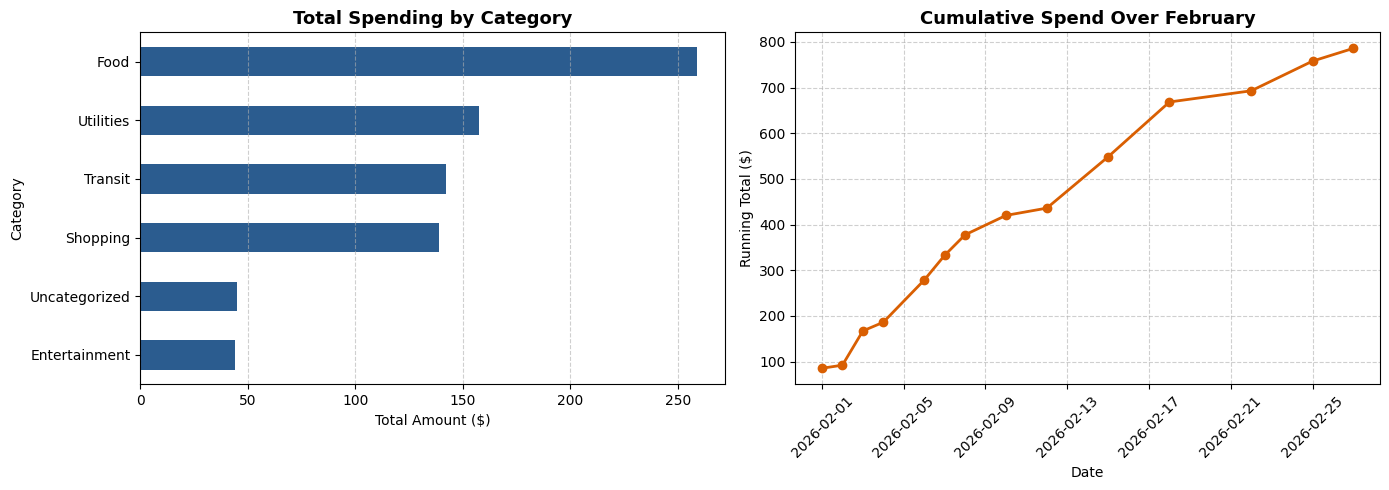

In [5]:
# Create a figure with 2 subplots side-by-side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# -----------------
# Chart 1: Spending by Category (Horizontal Bar Chart)
# -----------------
category_totals.sort_values().plot(kind="barh", color="#2b5c8f", ax=ax1)
ax1.set_title("Total Spending by Category", fontsize=13, weight="bold")
ax1.set_xlabel("Total Amount ($)")
ax1.grid(axis="x", linestyle="--", alpha=0.6)

# -----------------
# Chart 2: Cumulative Spending Over Time (Line Chart)
# -----------------
df["CumulativeSpend"] = df["Amount"].cumsum()
ax2.plot(
    df["Date"],
    df["CumulativeSpend"],
    marker="o",
    color="#d95f02",
    linewidth=2,
)
ax2.set_title("Cumulative Spend Over February", fontsize=13, weight="bold")
ax2.set_xlabel("Date")
ax2.set_ylabel("Running Total ($)")
ax2.tick_params(axis="x", rotation=45)
ax2.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

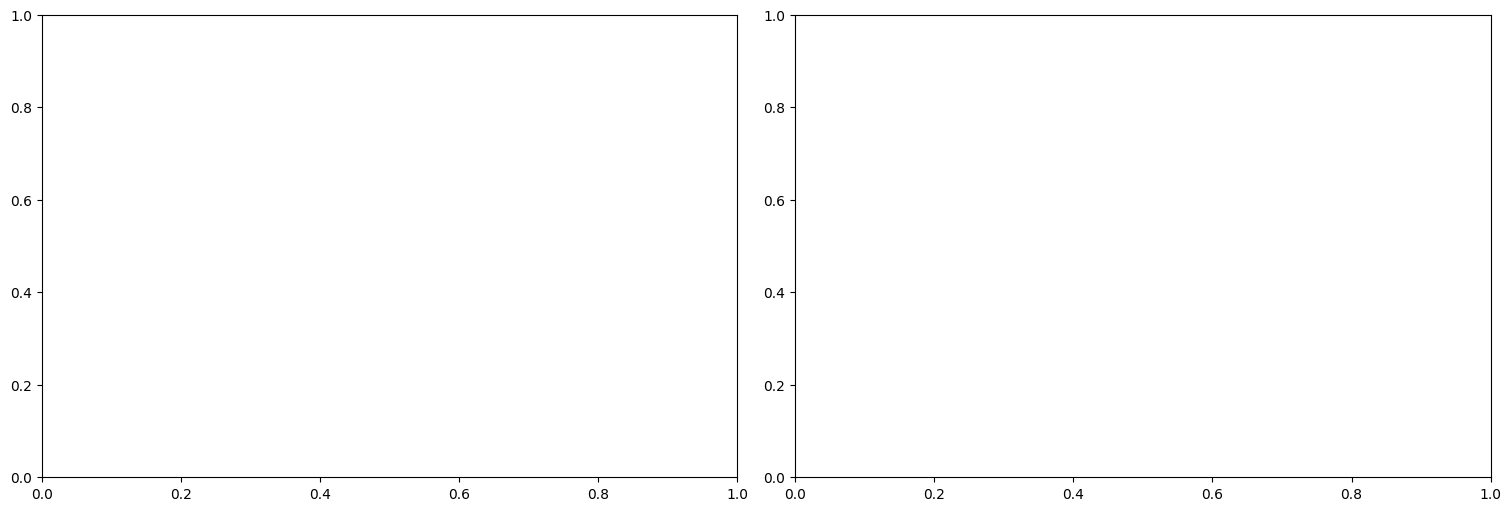

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5), layout="constrained")

In [7]:
plt.tight_layout(pad=2.0)
plt.show()

<Figure size 640x480 with 0 Axes>

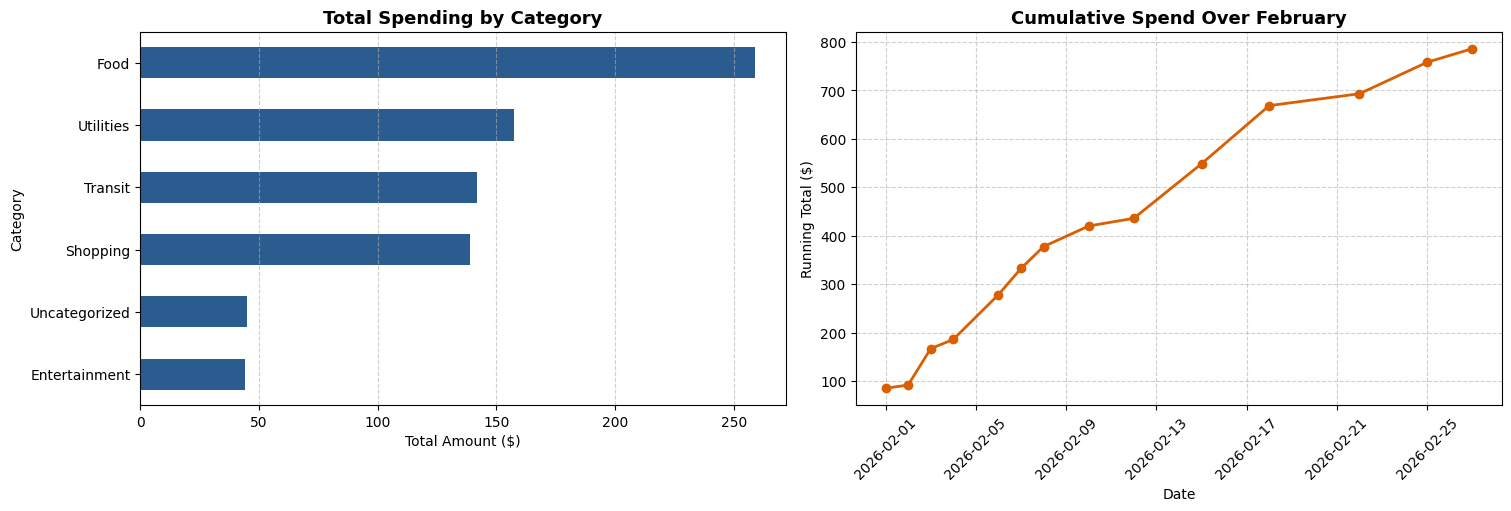

In [8]:
# All plotting and layout code must stay together in one cell
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5), layout="constrained")

# --- Chart 1: Spending by Category ---
category_totals.sort_values().plot(kind="barh", color="#2b5c8f", ax=ax1)
ax1.set_title("Total Spending by Category", fontsize=13, weight="bold")
ax1.set_xlabel("Total Amount ($)")
ax1.grid(axis="x", linestyle="--", alpha=0.6)

# --- Chart 2: Cumulative Spending Over Time ---
df["CumulativeSpend"] = df["Amount"].cumsum()
ax2.plot(
    df["Date"],
    df["CumulativeSpend"],
    marker="o",
    color="#d95f02",
    linewidth=2,
)
ax2.set_title("Cumulative Spend Over February", fontsize=13, weight="bold")
ax2.set_xlabel("Date")
ax2.set_ylabel("Running Total ($)")
ax2.tick_params(axis="x", rotation=45)
ax2.grid(True, linestyle="--", alpha=0.6)

plt.show()

In [9]:
# Add this right above plt.show()
plt.savefig("expense_analysis.png", dpi=300, bbox_inches="tight")
plt.show()

<Figure size 640x480 with 0 Axes>